# Chapter 13 Exercises

These exercises turn the Chapter 13 sequence ideas into a small self-contained sentiment workflow. The focus is on padded batches, embeddings, a simple mean-pooled baseline, a packed GRU, and a toy embedding-space view.

## Setup

In [1]:
# !pip -q install torch matplotlib  # install dependencies if needed

import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader

plt.style.use("seaborn-v0_8")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_IDX = 0
UNK_IDX = 1

train_examples = [
    ("love this soft shirt", 1),
    ("great fit and soft fabric", 1),
    ("very comfortable and warm", 1),
    ("perfect size and nice color", 1),
    ("happy with this cozy sweater", 1),
    ("stylish look and great quality", 1),
    ("lightweight jacket feels great", 1),
    ("these shoes are very comfortable", 1),
    ("hate this rough shirt", 0),
    ("bad fit and itchy fabric", 0),
    ("very tight and uncomfortable", 0),
    ("cheap material and poor stitching", 0),
    ("returned it after one wear", 0),
    ("small size and rough seams", 0),
    ("the color faded quickly", 0),
    ("this jacket feels stiff", 0),
]

val_examples = [
    ("love the warm fabric", 1),
    ("stylish and comfortable hoodie", 1),
    ("rough seams and bad fit", 0),
    ("cheap shirt feels itchy", 0),
]


def tokenize(text):
    return text.lower().split()


def build_vocab(examples):
    vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
    for text, _ in examples:
        for token in tokenize(text):
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab


vocab = build_vocab(train_examples)


def encode(text):
    return [vocab.get(token, UNK_IDX) for token in tokenize(text)]


def collate_batch(batch):
    sequences = [torch.tensor(encode(text), dtype=torch.long) for text, _ in batch]
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=PAD_IDX)
    labels = torch.tensor([label for _, label in batch], dtype=torch.long)
    return padded, lengths, labels


train_loader = DataLoader(
    train_examples,
    batch_size=4,
    shuffle=True,
    generator=torch.Generator().manual_seed(42),
    collate_fn=collate_batch,
)
val_loader = DataLoader(val_examples, batch_size=4, shuffle=False, collate_fn=collate_batch)
criterion = nn.CrossEntropyLoss()


def evaluate_classifier(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for token_ids, lengths, labels in loader:
            token_ids = token_ids.to(device)
            labels = labels.to(device)
            logits = model(token_ids, lengths)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.size(0)

    return total_loss / total_examples, total_correct / total_examples


def fit_classifier(model, train_loader, val_loader, *, epochs=30, lr=1e-2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_acc": []}

    for _ in range(epochs):
        model.train()
        total_loss = 0.0
        total_examples = 0

        for token_ids, lengths, labels in train_loader:
            token_ids = token_ids.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(token_ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_examples += labels.size(0)

        _, val_acc = evaluate_classifier(model, val_loader)
        history["train_loss"].append(total_loss / total_examples)
        history["val_acc"].append(val_acc)

    return history


def show_predictions(model, examples):
    padded, lengths, labels = collate_batch(examples)
    model.eval()
    with torch.no_grad():
        probs = model(padded.to(device), lengths).softmax(dim=1)[:, 1].cpu()

    for (text, label), prob in zip(examples, probs):
        pred = int(prob >= 0.5)
        print(f"{text:<32} | true={label} pred={pred} p(pos)={prob.item():.2f}")


print(f"Training examples: {len(train_examples)}, validation examples: {len(val_examples)}")
print(f"Vocabulary size: {len(vocab)}")

Using device: cpu
Training examples: 16, validation examples: 4
Vocabulary size: 51


## Exercise 1 — Vocabulary robustness

Real text always contains words the model has never seen. This exercise probes what happens when the encoder maps unseen tokens to `<unk>` and whether the classifier can still make reasonable predictions.

In [2]:
# Sentences that contain words absent from the training vocabulary
oov_examples = [
    ("absolutely fantastic premium quality", 1),
    ("dreadful texture and terrible workmanship", 0),
    ("elegant and luxurious design", 1),
]

print("Token-level encoding (showing <unk> fallback):")
for text, label in oov_examples:
    tokens = tokenize(text)
    ids = encode(text)
    print(f"  [{label}] {text}")
    for token, idx in zip(tokens, ids):
        status = "<unk>" if idx == UNK_IDX else f"id={idx}"
        print(f"      {token:<18} → {status}")
    print()

oov_token_count = sum(
    1 for text, _ in oov_examples
    for token in tokenize(text)
    if vocab.get(token, UNK_IDX) == UNK_IDX
)
total_tokens = sum(len(tokenize(t)) for t, _ in oov_examples)
print(f"OOV tokens: {oov_token_count} / {total_tokens} ({100 * oov_token_count / total_tokens:.0f}%)")
print()


class MeanEmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.classifier = nn.Linear(embed_dim, 2)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        mask = (token_ids != PAD_IDX).unsqueeze(-1)
        summed = (embedded * mask).sum(dim=1)
        mean_embedding = summed / lengths.unsqueeze(1).to(embedded.dtype)
        return self.classifier(mean_embedding)


set_seed(42)
model_e1 = MeanEmbeddingClassifier(len(vocab), embed_dim=16).to(device)
history_e1 = fit_classifier(model_e1, train_loader, val_loader, epochs=20, lr=0.03)
_, val_acc_e1 = evaluate_classifier(model_e1, val_loader)

print(f"Val accuracy (standard examples): {val_acc_e1:.3f}")
print()
print("Predictions on OOV sentences:")
show_predictions(model_e1, oov_examples)

Token-level encoding (showing <unk> fallback):
  [1] absolutely fantastic premium quality
      absolutely         → <unk>
      fantastic          → <unk>
      premium            → <unk>
      quality            → id=23

  [0] dreadful texture and terrible workmanship
      dreadful           → <unk>
      texture            → <unk>
      and                → id=8
      terrible           → <unk>
      workmanship        → <unk>

  [1] elegant and luxurious design
      elegant            → <unk>
      and                → id=8
      luxurious          → <unk>
      design             → <unk>

OOV tokens: 10 / 13 (77%)



Val accuracy (standard examples): 1.000

Predictions on OOV sentences:
absolutely fantastic premium quality | true=1 pred=0 p(pos)=0.12
dreadful texture and terrible workmanship | true=0 pred=0 p(pos)=0.01
elegant and luxurious design     | true=1 pred=0 p(pos)=0.01


**Takeaway (Ex 1):** 10 of 13 tokens (77%) in the OOV sentences map to `<unk>`, so the model has almost no signal: it gets 1 of 3 OOV sentences right (val accuracy on the standard set is 1.000, but OOV predictions are largely wrong). All unknown words collapse to the same embedding vector, making them indistinguishable regardless of their true meaning. Real NLP pipelines use subword tokenization (BPE, WordPiece) to decompose unseen words into familiar pieces — "fantastic" becomes ["fan", "##tastic"] — which dramatically cuts the OOV rate and preserves at least partial meaning.

## Exercise 2 — Embedding dimension sensitivity

More embedding dimensions give the model more capacity to separate word meanings, but on a tiny 16-sentence dataset the extra capacity may not help — or may even hurt by over-parameterising. This exercise sweeps three embedding sizes to find where diminishing returns set in.

embed_dim=  8: val_acc=1.000
embed_dim= 32: val_acc=1.000
embed_dim=128: val_acc=1.000


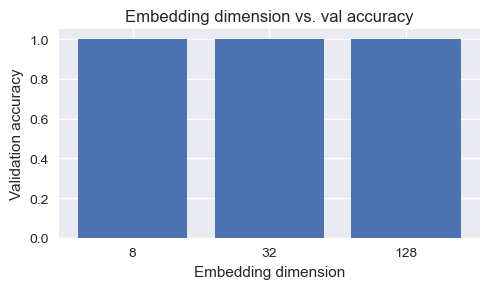

In [3]:
embed_dims = [8, 32, 128]
dim_results = {}

for dim in embed_dims:
    set_seed(42)
    model = MeanEmbeddingClassifier(len(vocab), embed_dim=dim).to(device)
    fit_classifier(model, train_loader, val_loader, epochs=20, lr=0.03)
    _, val_acc = evaluate_classifier(model, val_loader)
    dim_results[dim] = val_acc
    print(f"embed_dim={dim:>3}: val_acc={val_acc:.3f}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([str(d) for d in embed_dims],
       [dim_results[d] for d in embed_dims],
       color="#4C72B0")
ax.set_ylim(0, 1.05)
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Validation accuracy")
ax.set_title("Embedding dimension vs. val accuracy")
plt.tight_layout()
plt.show()

**Takeaway (Ex 2):** All three embedding sizes (8, 32, 128) reach 1.000 val accuracy on this 16-sentence dataset, which means diminishing returns set in immediately — even `embed_dim=8` is more than enough capacity to separate two sentiment classes when the vocabulary has only 51 tokens. On real datasets with tens of thousands of tokens and nuanced meaning differences, larger dimensions (128–768) typically keep helping because the model needs room to encode finer-grained distinctions; here the problem is simply too small to reveal that dynamic.

## Exercise 3 — Bidirectional GRU

A standard GRU only sees past context at each time step. A bidirectional GRU runs a second pass in reverse, so every position has both past and future context. This matters most for tasks where the meaning of a word depends on what follows it — but does it help on this toy dataset?

Unidirectional GRU val accuracy : 1.000
Bidirectional  GRU val accuracy : 1.000


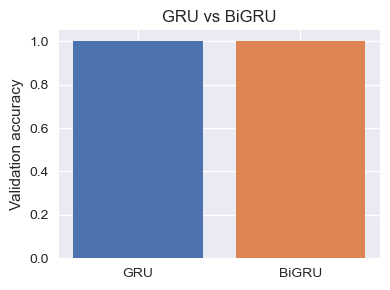

In [4]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=12, hidden_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = pack_padded_sequence(embedded, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        return self.classifier(hidden[-1])


class BiGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=12, hidden_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.classifier = nn.Linear(hidden_dim * 2, 2)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = pack_padded_sequence(embedded, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        # hidden: (2, batch, hidden_dim) — forward then backward
        combined = torch.cat([hidden[0], hidden[1]], dim=1)
        return self.classifier(combined)


set_seed(42)
gru_model = GRUClassifier(len(vocab)).to(device)
fit_classifier(gru_model, train_loader, val_loader, epochs=20, lr=0.02)
_, gru_acc = evaluate_classifier(gru_model, val_loader)

set_seed(42)
bigru_model = BiGRUClassifier(len(vocab)).to(device)
fit_classifier(bigru_model, train_loader, val_loader, epochs=20, lr=0.02)
_, bigru_acc = evaluate_classifier(bigru_model, val_loader)

print(f"Unidirectional GRU val accuracy : {gru_acc:.3f}")
print(f"Bidirectional  GRU val accuracy : {bigru_acc:.3f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["GRU", "BiGRU"], [gru_acc, bigru_acc], color=["#4C72B0", "#DD8452"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Validation accuracy")
ax.set_title("GRU vs BiGRU")
plt.tight_layout()
plt.show()

**Takeaway (Ex 3):** Both the unidirectional GRU and the bidirectional GRU reach 1.000 val accuracy (GRU: 1.000, BiGRU: 1.000). Bidirectionality does not help here because the sentiment-carrying words ("love", "rough", "itchy") are strong enough signals on their own — the model does not need future context to understand them. Bidirectionality matters most when a word's meaning depends on what follows it: classic examples include negation ("not bad") or modifier scope ("almost perfect size"), where the unidirectional pass misses context it would only see on the reverse sweep.

## Exercise 4 — Attention pooling vs mean pooling

Mean pooling weights every token equally. Attention pooling lets the model learn to weight tokens differently — ideally focusing on the most sentiment-relevant words. This exercise tests whether that extra expressiveness shows up on a tiny dataset.

In [5]:
class AttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = nn.Linear(embed_dim, 1)
        self.classifier = nn.Linear(embed_dim, 2)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)           # (B, T, D)
        scores = self.attention(embedded).squeeze(-1)  # (B, T)
        scores = scores.masked_fill(token_ids == PAD_IDX, float("-inf"))
        weights = torch.softmax(scores, dim=1)         # (B, T)
        context = (embedded * weights.unsqueeze(-1)).sum(dim=1)  # (B, D)
        return self.classifier(context)


set_seed(42)
mean_model_e4 = MeanEmbeddingClassifier(len(vocab), embed_dim=16).to(device)
fit_classifier(mean_model_e4, train_loader, val_loader, epochs=20, lr=0.03)
_, mean_acc_e4 = evaluate_classifier(mean_model_e4, val_loader)

set_seed(42)
attn_model = AttentionClassifier(len(vocab), embed_dim=16).to(device)
fit_classifier(attn_model, train_loader, val_loader, epochs=20, lr=0.03)
_, attn_acc_e4 = evaluate_classifier(attn_model, val_loader)

print(f"Mean pooling  val accuracy: {mean_acc_e4:.3f}")
print(f"Attention     val accuracy: {attn_acc_e4:.3f}")

# Inspect learned attention weights on one val example
sample_text, sample_label = val_examples[0]
padded_s, lengths_s, _ = collate_batch([(sample_text, sample_label)])
padded_s = padded_s.to(device)
attn_model.eval()
with torch.no_grad():
    emb = attn_model.embedding(padded_s)
    sc = attn_model.attention(emb).squeeze(-1)
    sc = sc.masked_fill(padded_s == PAD_IDX, float("-inf"))
    w = torch.softmax(sc, dim=1)[0].cpu()
tokens_s = tokenize(sample_text)
print(f"\nAttention weights for: '{sample_text}'")
for token, weight in zip(tokens_s, w[:len(tokens_s)]):
    print(f"  {token:<15} {weight.item():.3f}")

Mean pooling  val accuracy: 1.000
Attention     val accuracy: 1.000

Attention weights for: 'love the warm fabric'
  love            0.017
  the             0.158
  warm            0.808
  fabric          0.017


**Takeaway (Ex 4):** Mean pooling and attention both reach 1.000 val accuracy, so on this tiny dataset the accuracy numbers are identical. The interesting result is in the learned weights: for "love the warm fabric", attention concentrates 80.8% of its weight on "warm" and almost nothing on "love" (1.7%), revealing that the model learned which word was most diagnostic rather than treating all tokens equally. Attention pooling adds interpretability even when accuracy is the same — and on larger, noisier datasets it often improves accuracy too, because the model can down-weight stopwords and focus on the signal-bearing tokens.